# Lesson 162 · The relational FM vision

Standalone Tier C mechanism/design audit. Three live TODOs; standard-library computation, no downloads or model training. All fixture inputs and functions are embedded. Course links become public only after publication. Complete the map yourself; author preparation is not learner mastery.

<!-- course-portable:start -->
### Follow the computation

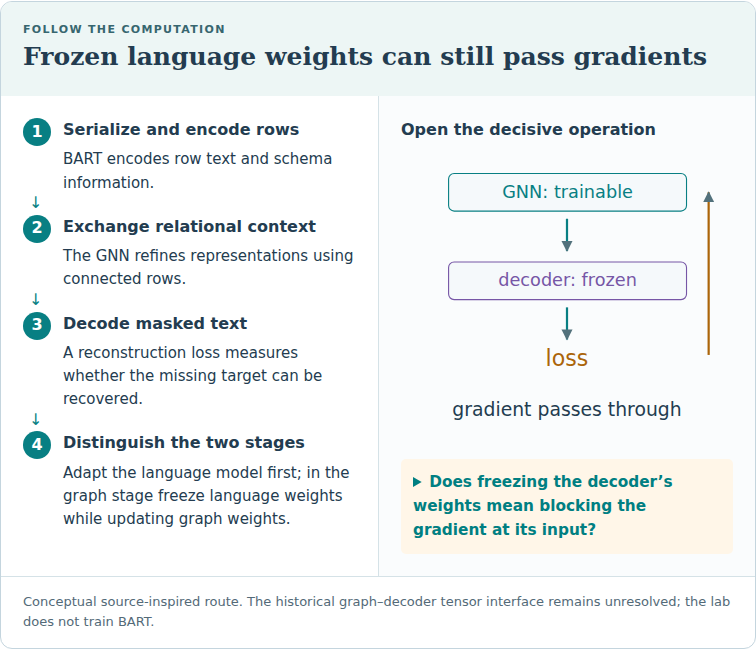

Conceptual source-inspired route. The historical graph–decoder tensor interface remains unresolved; the lab does not train BART.

**Trace question:** Does freezing the decoder’s weights mean blocking the gradient at its input?

**Trace answer:** No. A fixed differentiable decoder can still transmit the loss gradient to the GNN that supplied its input.
<!-- course-portable:end -->

<div class="lab-access"><strong>Lesson package</strong> · <a href="https://avistian.github.io/relational/labs/0162-the-relational-fm-vision.ipynb">Student notebook</a> · <a href="https://avistian.github.io/relational/labs/html/0162-the-relational-fm-vision.html">Executed author preview</a> · <a href="https://avistian.github.io/relational/labs/solutions/0162-the-relational-fm-vision.ipynb">Solution</a><br><a href="https://avistian.github.io/relational/reference/relational-fm-vision.html">Quick reference</a> · <a href="https://avistian.github.io/relational/labs/l162-vision-map-template.md">Vision map template</a> · <a href="https://avistian.github.io/relational/labs/l162-reproduction.md">Reproduction contract</a> · <a href="https://avistian.github.io/relational/labs/evidence/l162/report.md">Complete local audit</a></div>

## 1 · A row is a starting point, not the whole database

**Single win:** explain how a row language model and a graph could work together, then turn that architecture into a testable opportunities/obstacles map. Read the main argument first; complete the notebook and map in a separate practice session.

[Lesson 159](https://avistian.github.io/relational/lessons/0159-foundation-model-preview.html) supplied masked reconstruction objectives: hide an item and learn to recover it. [Lesson 161](https://avistian.github.io/relational/lessons/0161-what-is-a-foundation-model.html) asked what makes a learned starting point reusable. Neither objective nor definition explains how related tables enter a prediction. This lesson connects them through Vogel, Hilprecht and Binnig’s [2023 relational foundation-model vision](https://arxiv.org/html/2305.15321v1#S2).

Recall why masking a value is not proof of transfer; distinguish frozen weights from frozen inputs.

**Worked example.** A database has rows about moons, their planets and their stars. A moon row carries a planet key. That planet carries a star key. A language model that reads only the moon’s text cannot directly read a star’s attributes. We need a route between the rows before we can ask whether those attributes help.

A **primary key** identifies a row. A **foreign key** refers to a row in another table. A **graph** represents entities as nodes and relationships as edges. **Message passing** updates a node’s representation using representations from its neighbors. One **hop** crosses one edge. These definitions concern information access; useful prediction still has to be learned and tested.

> **In plain terms.** Let the language model read a manageable piece. Let the graph connect pieces that belong together. Then test whether those connections help.

## 2 · Model architecture: text inside rows, context between rows

**Reading route.** Follow the moon row through the encoder, graph and decoder first. Then return to the two training stages. The forward arrows carry representations; the backward training signal changes only the weights that are allowed to learn.

A **language model (LM)** learns patterns in token sequences. A **token** is a piece of text recognized by its tokenizer. **Serialization** turns structured values and schema names into a sequence. An **encoder** turns that sequence into numerical representations; a **decoder** uses representations to generate output text. An **embedding** is a learned vector representing an input.

The paper’s proposal combines row-wise LM encoding with a graph neural network (**GNN**) and a task head. Its prototype uses BART, an encoder–decoder LM, and a graph convolutional network (**GCN**), a form of neighborhood aggregation. Row serialization includes table and column names. [Paper §§2–4](https://arxiv.org/html/2305.15321v1#S2)

<figure class="route-figure" tabindex="0">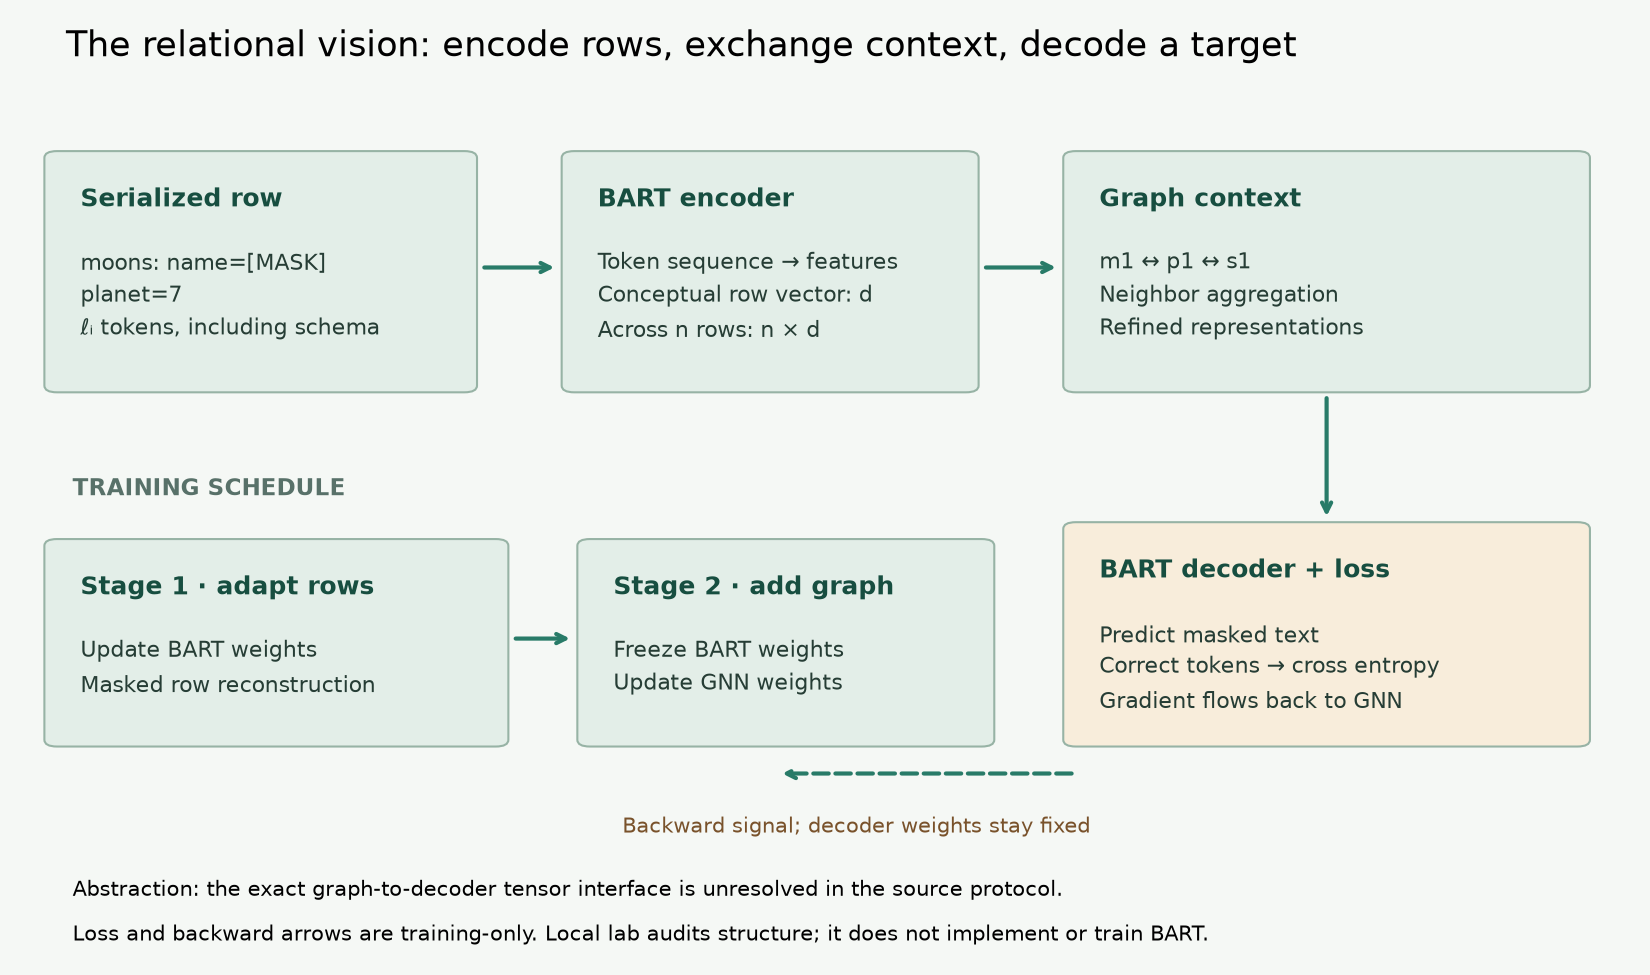<figcaption>Source-inspired conceptual architecture, not a released tensor specification. The decoder loss trains graph weights through frozen LM operations. n counts rows, d counts representation features; the historical graph/decoder interface is unresolved.</figcaption></figure>

**Trace the forward pass.** Start with a row such as `moons: name=[MASK]; planet=7`. `[MASK]` marks withheld content. After tokenization, the row has length ℓᵢ tokens, where i identifies the row. The encoder produces a representation of width d, where d is a feature count. Across n rows, a conceptual row-vector array has shape n×d. A graph operation combines connected representations. A decoder then predicts tokens for the withheld name.

**What the drawing abstracts.** The paper describes representations at cell, column and table levels, but does not specify enough of the graph/decoder interface to reconstruct the exact released tensor routing. The n×d row-vector view is an explanatory abstraction. Decoder inputs may require a sequence or projection. The figure deliberately leaves that historical interface unresolved rather than inventing its shape.

**Two training stages.** First adapt BART on masked row reconstruction. Then freeze its parameters while training the GNN to improve reconstruction through graph context. A **parameter** is a learned weight; freezing means not updating it. A **gradient** measures how a change affects the loss. **Cross entropy** penalizes low probability assigned to the correct output token. The frozen decoder still needs to pass gradients back to the GNN. Turning off all differentiation through the decoder would prevent that training signal. The source also discusses joint end-to-end training as a more costly alternative, not the reported staged recipe. [Paper §§3–4](https://arxiv.org/html/2305.15321v1#S3)

**Mask before encoding.** If a hidden name remains visible in another serialized copy or a cached clean embedding, reconstruction can leak its answer. L159 examined that danger. Here we trace access to representations; the local audit neither tokenizes real data nor trains BART.

## 3 · Context is a path, not a promise

Predict: remove p1 while retaining m1 and s1. Is a two-hop route still available? Explain before reading the trace.

Our course graph has five nodes: moon rows m1 and m2, planet p1, star s1, and unrelated row z1. The edges m1—p1, m2—p1 and p1—s1 pass information both ways. This is an explicitly chosen teaching graph, not a reconstruction of the paper’s undocumented graph construction.

<figure class="route-figure" tabindex="0">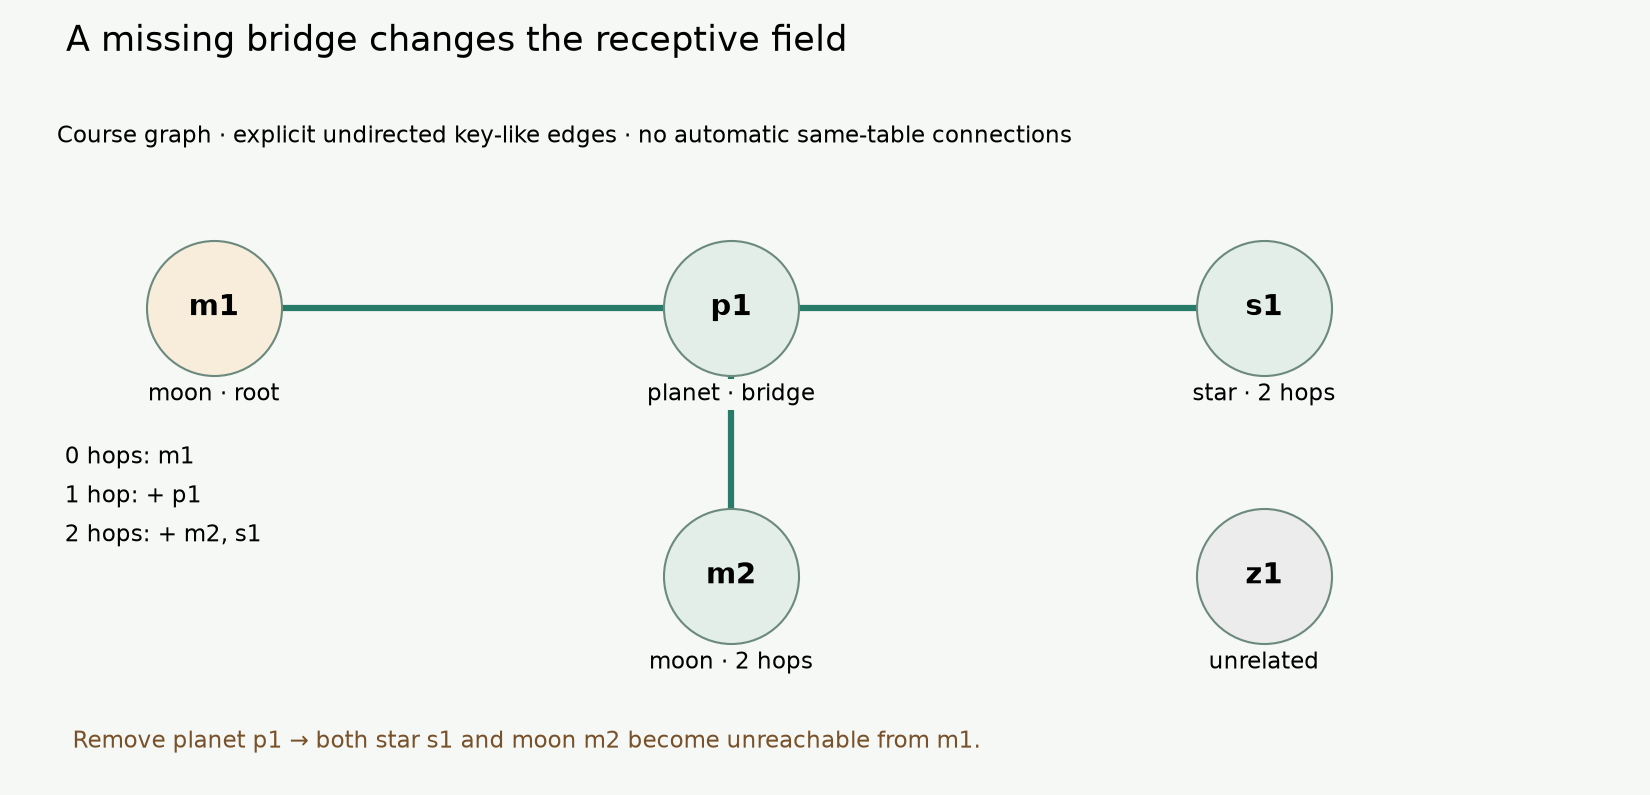<figcaption>Course graph at two hops with all three edges: m1, p1, m2 and s1 are reachable; z1 is not. Remove planet p1 before traversal and only m1 remains. Reachability is potential access, not a prediction.</figcaption></figure>

**Worked trace.** Starting at m1, zero hops retain only m1. One hop adds p1. Two hops add m2 and s1. The unrelated z1 remains unreachable. Reaching m2 uses two key edges through the shared planet; the example does not add an automatic same-table edge.

A **receptive field** is the set of inputs that can potentially affect an output through the available computation. Reachability is a structural upper bound: learned weights might suppress a message, and an accessible value might be irrelevant. More reachable rows do not guarantee higher accuracy.

**Remove an intermediate table.** If we exclude planets, we remove p1 and its incident edges before traversing. The retained moon and star tables do not create a shortcut. An **induced subgraph** retains chosen nodes and only edges whose two endpoints remain. Neighborhood limits can lower graph work, but also discard useful context. This is one scale–context trade-off discussed in the paper. [§3, efficient learning](https://arxiv.org/html/2305.15321v1#S3)

Static intervention: two hops with all edges reaches m1/m2/p1/s1; deleting p1 leaves m1 only.

**Lab task 1 — `reachable_rows`.** Implement the traversal over the induced graph. Return sorted unique row IDs reachable within at most h hops, including the root. Test an excluded intermediate table and a disconnected row. The CHECK must reject a solution that simply returns all rows.

## 4 · Many rows and wide rows are different obstacles

**A row input can fit while the table does not.** Suppose two serialized rows have 3 and 5 tokens. Joining them gives 8 tokens. A simple dense attention score matrix compares every token with every token: 8×8=64 ordered pairs. Separate row inputs give 3×3+5×5=34 pairs. The missing cross-row token comparisons explain why another mechanism is needed for context.

Let ℓᵢ denote each row length. The hypothetical whole-table pair count is `(Σᵢ ℓᵢ)²`; independent rows give `Σᵢ ℓᵢ²`. The symbol Σ means “sum over rows.” These are counts for one dense attention score pattern, not measured speed, total model floating-point operations (FLOPs) or memory. Graph computation, decoder work, other transformer operations and padding are absent.

**A wide row can still fail.** The source identifies a 1024-token BART input limit. A row with 1100 serialized tokens exceeds it by 76. Processing rows independently does not solve that case. Truncating loses information; splitting columns may change which facts can interact. Schema and special tokens also consume the real input budget. [Paper §3, wide tables](https://arxiv.org/html/2305.15321v1#S3)

Static trace: row lengths 3/5 give 64 whole-table pairs and 34 row pairs. Limit 4 drops 1 token and leaves 25 row pairs.

**Fixed baseline.** The widget starts at two rows of 3/5 tokens and limit 4, deliberately small enough to count by hand. Whole-table pairs = 64, independent-row pairs = 34, and truncated-row pairs = 3² + 4² = 25. One token is dropped. The smaller 25 is purchased by deleting input; it is not a free improvement. The wide-row preset uses 1100/18/22 tokens and the source’s 1024-token limit.

**Lab task 2 — `token_budget`.** Return both untruncated pair counts, retained pair count, dropped tokens and overflowing row indices. Use supplied synthetic lengths, without claiming to run a tokenizer. An input length of zero is legal in this arithmetic exercise; actual BART inputs generally contain special tokens.

## 5 · What the initial experiment actually establishes

The vision is pretraining across diverse relational databases and reuse on new ones. The initial evaluation instead uses single-table corpora, wikiTables and gitTables, for reconstruction. The authors use 10,000 tables per corpus, a 70/20/10 split, best-validation-accuracy checkpoints and three-run means. Graph context within a table can help without demonstrating foreign-key transfer across unseen databases. [Paper §4](https://arxiv.org/html/2305.15321v1#S4)

| wikiTables reconstruction task | Published BART_table accuracy | Published +GNN accuracy |
|---|---:|---:|
| Missing cell values |20.75%|46.15%|
| Column names |66.88%|83.91%|
| Table names |36.99%|37.85%|

These are published Table 1 targets, not this lesson’s results. The missing-value difference is 25.40 percentage points; it is not a 25.40% relative improvement. Neither that difference nor the table-name result isolates all confounders of additional graph training.

> **Full-reproduction boundary.** The selected target is the complete wikiTables two-arm, three-task, three-run comparison. Exact subsets/splits, matching implementation and important configuration details remain unavailable in our bounded source search. Historical reproduction is **NOT_RUN**, and fidelity is **NOT_ESTABLISHED**. The runnable local audit below is a different experiment. See the [protocol and source-gap ledger](https://avistian.github.io/relational/labs/l162-reproduction.md).

**Lab task 3 — `evidence_verdict`.** Check six evidence declarations: multi-table evaluation, held-out database identity, audited pretraining provenance, legal adaptation, a matched baseline and verified predictions. Collect every missing item. If all six are present, return `TRANSFER_REVIEW_ELIGIBLE`; retain transfer=`NOT_ESTABLISHED` until the evidence itself receives review. `RECONSTRUCTION_ONLY` and `MULTITABLE_ONLY` describe maximum scope conditional on the record, not certified performance.

A **matched baseline** receives the declared comparable information and adaptation budget. **Legal adaptation** uses only labels and information allowed by the evaluation protocol, including query cutoffs. Verified prediction files still require appropriate metrics, uncertainty and scientific interpretation. A Boolean declaration cannot do that work.

## 6 · Build the opportunities and obstacles map

| Opportunity | Why the design might help | Obstacle | A test that could change your mind |
|---|---|---|---|
| Neighbor-table information | Paths expose related rows | Sampling can cut the necessary path | Compare full and cut paths on matched held-out queries |
| Many-row processing | LM inputs stay row-sized | Graph and total row encoding still grow | Measure end-to-end cost as row count increases |
| Reusable representations | Pretraining supplies a shared starting point | Connected corpora and database provenance | Hold out an entire database and compare with training from scratch |
| Numerical and typed information | Additional features can complement text | Numeric structure can be poorly preserved | Compare text-only and typed inputs on a prespecified task |

The paper discusses corpus availability, wide tables, graph efficiency and statistical features as open challenges. The tests above are course proposals, not experiments the paper completed. L163 will examine row encoding choices; L164 introduces Griffin. This lesson supplies the questions to carry into those readings.

**Executed author audit:** all 16 graph interventions, 8 token cases and 64 evidence configurations completed. Of the evidence fixtures, 32 have a reconstruction-only scope ceiling, 31 a multi-table-only ceiling and 1 is eligible for transfer review. All 64 retain transfer **NOT_ESTABLISHED**. These are synthetic declarations, not benchmark populations. [Complete output](https://avistian.github.io/relational/labs/evidence/l162/report.md).

**Practice sequence.** Predict the graph and token examples before running code. Implement the three functions and complete every CHECK. Write a 400–600-word map using the [template](https://avistian.github.io/relational/labs/l162-vision-map-template.md), including an explicit adaptation budget and a disconfirming result for your proposed transfer experiment. Keep the map’s arguments distinct from the deterministic audit’s outputs.

Explain why an LM+GNN can improve reconstruction without establishing transfer. Include architecture, training stages and evidence gaps.

**Exit criterion.** Human review scores architecture, context/scale arithmetic, causal mapping, source boundaries and falsifiable evaluation from 0–2 each. Aim for ≥ 8/10 with no zero. Author execution is preparation; your status remains **PENDING_WRITTEN_DEFENSE** until your own work is assessed. Existing Year 4 exit gates remain unchanged.

Tomorrow, redraw m1→p1→s1 and explain why row count differs from row width. In one week, explain why a stronger reconstruction score need not imply transfer. Ask the teaching agent about any unclear step or paste your map for feedback.

**Primary reading:** Vogel, Hilprecht and Binnig, [Towards Foundation Models for Relational Databases, §§2–4](https://arxiv.org/html/2305.15321v1). Read the architecture beside its experiment boundaries.


In [1]:
# @colab-bootstrap — PROVIDED: Python 3.10+ standard library, no installs/downloads.
from pathlib import Path
import json,hashlib


## PROVIDED · All experiment inputs
Sixteen graph interventions, eight length/budget cases, all 64 evidence configurations. No random seed, fitted model or measured benchmark population.

In [2]:
fixture_text='{\n  "scope": "SYNTHETIC_COURSE_AUDIT",\n  "graph_cases": [\n    {\n      "id": "h0-cut0-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 0,\n      "allowed_tables": null\n    },\n    {\n      "id": "h0-cut0-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 0,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h0-cut1-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 0,\n      "allowed_tables": null\n    },\n    {\n      "id": "h0-cut1-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 0,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h1-cut0-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 1,\n      "allowed_tables": null\n    },\n    {\n      "id": "h1-cut0-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 1,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h1-cut1-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 1,\n      "allowed_tables": null\n    },\n    {\n      "id": "h1-cut1-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 1,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h2-cut0-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 2,\n      "allowed_tables": null\n    },\n    {\n      "id": "h2-cut0-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 2,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h2-cut1-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 2,\n      "allowed_tables": null\n    },\n    {\n      "id": "h2-cut1-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 2,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h3-cut0-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 3,\n      "allowed_tables": null\n    },\n    {\n      "id": "h3-cut0-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ],\n        [\n          "p1",\n          "s1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 3,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    },\n    {\n      "id": "h3-cut1-restricted0",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 3,\n      "allowed_tables": null\n    },\n    {\n      "id": "h3-cut1-restricted1",\n      "nodes": {\n        "m1": "moons",\n        "m2": "moons",\n        "p1": "planets",\n        "s1": "stars",\n        "z1": "isolated"\n      },\n      "edges": [\n        [\n          "m1",\n          "p1"\n        ],\n        [\n          "m2",\n          "p1"\n        ]\n      ],\n      "root": "m1",\n      "hops": 3,\n      "allowed_tables": [\n        "moons",\n        "stars",\n        "isolated"\n      ]\n    }\n  ],\n  "token_cases": [\n    {\n      "lengths": [\n        3,\n        5\n      ],\n      "limit": 8\n    },\n    {\n      "lengths": [\n        3,\n        5\n      ],\n      "limit": 1024\n    },\n    {\n      "lengths": [\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8\n      ],\n      "limit": 8\n    },\n    {\n      "lengths": [\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8,\n        8\n      ],\n      "limit": 1024\n    },\n    {\n      "lengths": [\n        1100,\n        18,\n        22\n      ],\n      "limit": 8\n    },\n    {\n      "lengths": [\n        1100,\n        18,\n        22\n      ],\n      "limit": 1024\n    },\n    {\n      "lengths": [\n        0,\n        1\n      ],\n      "limit": 8\n    },\n    {\n      "lengths": [\n        0,\n        1\n      ],\n      "limit": 1024\n    }\n  ],\n  "evidence_cases": [\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": false,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": false,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": false,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": false,\n      "matched_baseline": true,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": false,\n      "predictions_verified": true\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": false\n    },\n    {\n      "multitable": true,\n      "heldout_database": true,\n      "pretraining_audited": true,\n      "adaptation_legal": true,\n      "matched_baseline": true,\n      "predictions_verified": true\n    }\n  ]\n}\n'
assert hashlib.sha256(fixture_text.encode()).hexdigest()=='212391a68cff829944d861a3ebabaad64b3da507e3ebd3ec3edcd68a3d85e991'
packet=json.loads(fixture_text)

## TODO · reachable_rows

**Goal:** Implement at-most-hop reachability on the induced graph.

**Contract:** nodes maps canonical nonempty row IDs to canonical nonempty table IDs; edges is a list of unique undirected pairs of distinct known nodes. hops is a nonnegative integer, excluding bool. allowed_tables is None or a nonempty list of unique known tables including the root table. Reject invalid inputs with ValueError. Filter nodes/edges before traversal; include root, return sorted unique IDs; do not mutate inputs.

Predict an edge case before implementing.

In [3]:
def reachable_rows(nodes, edges, root, hops, allowed_tables=None):
    """At most hops on an undirected, table-filtered graph; include the root."""
    valid_id = lambda x: isinstance(x,str) and bool(x) and x.strip()==x
    if not isinstance(nodes,dict) or not nodes or not all(valid_id(k) and valid_id(v) for k,v in nodes.items()):
        raise ValueError('Canonical nonempty node and table IDs required')
    if type(hops) is not int or hops<0 or root not in nodes:
        raise ValueError('Known root and nonnegative integer hops required')
    if not isinstance(edges,list):raise ValueError('Edges must be a list')
    seen_edges=set()
    for edge in edges:
        if not isinstance(edge,(list,tuple)) or len(edge)!=2 or not all(isinstance(x,str) and x in nodes for x in edge) or edge[0]==edge[1]:
            raise ValueError('Edges need two distinct known endpoints')
        pair=tuple(sorted(edge))
        if pair in seen_edges:raise ValueError('Duplicate undirected edge')
        seen_edges.add(pair)
    if allowed_tables is None:allowed=set(nodes.values())
    else:
        if not isinstance(allowed_tables,list) or not allowed_tables or not all(isinstance(t,str) and t in nodes.values() for t in allowed_tables) or len(set(allowed_tables))!=len(allowed_tables):
            raise ValueError('Unique known table list required')
        allowed=set(allowed_tables)
    if nodes[root] not in allowed:raise ValueError('Root table must be retained')
    adjacency={n:set() for n,t in nodes.items() if t in allowed}
    for a,b in seen_edges:
        if a in adjacency and b in adjacency:
            adjacency[a].add(b);adjacency[b].add(a)
    visited={root};frontier={root}
    for _ in range(hops):
        frontier={v for u in frontier for v in adjacency[u]}-visited
        visited.update(frontier)
        if not frontier:break
    return sorted(visited)

In [4]:
# CHECK
assert reachable_rows({"m1":"moons","p1":"planets","s1":"stars"},[["m1","p1"],["p1","s1"]],"m1",2,["moons","stars"])==["m1"]
print("CHECK: removing the intermediate table breaks the path")

CHECK: removing the intermediate table breaks the path


## TODO · token_budget

**Goal:** Expose the information price of truncation.

**Contract:** lengths is a nonempty list of nonnegative integers; limit is a positive integer. Reject booleans, floats and invalid inputs with ValueError. Return rows, total_tokens, retained_tokens, dropped_tokens, overflow_rows (zero-based indices), whole_table_pairs, row_pairs, retained_row_pairs. Whole-table and row pairs use original lengths; retained pairs use min(length,limit). No tokenization or total-compute claim.

Predict an edge case before implementing.

In [5]:
def token_budget(lengths, limit):
    """Dense attention pair proxies, not runtime or total LM/GNN memory."""
    if not isinstance(lengths,list) or not lengths or any(type(n) is not int or n<0 for n in lengths):
        raise ValueError('Nonempty list of nonnegative integer token counts required')
    if type(limit) is not int or limit<=0:raise ValueError('Positive integer limit required')
    kept=[min(n,limit) for n in lengths]
    return dict(rows=len(lengths),total_tokens=sum(lengths),retained_tokens=sum(kept),
                dropped_tokens=sum(lengths)-sum(kept),overflow_rows=[i for i,n in enumerate(lengths) if n>limit],
                whole_table_pairs=sum(lengths)**2,row_pairs=sum(n*n for n in lengths),retained_row_pairs=sum(n*n for n in kept))

In [6]:
# CHECK
r=token_budget([3,5],4)
assert (r["whole_table_pairs"],r["row_pairs"],r["retained_row_pairs"],r["dropped_tokens"])==(64,34,25,1)
print("CHECK: lower retained pair count deletes one token")

CHECK: lower retained pair count deletes one token


## TODO · evidence_verdict

**Goal:** Require evidence for the claim being made.

**Contract:** Accept exactly six Boolean fields in this order: multitable, heldout_database, pretraining_audited, adaptation_legal, matched_baseline, predictions_verified. Reject missing/extra fields or non-Booleans with ValueError. Collect false fields as MULTITABLE_EVALUATION, HELD_OUT_DATABASE, PRETRAINING_PROVENANCE, LEGAL_ADAPTATION, MATCHED_BASELINE, VERIFIED_PREDICTIONS in that order. Return supported=RECONSTRUCTION_ONLY if multitable is false, otherwise MULTITABLE_ONLY; if no missing items return TRANSFER_REVIEW_ELIGIBLE. Always return transfer=NOT_ESTABLISHED and missing=list. Scope ceilings are conditional, not authenticated evidence.

Predict an edge case before implementing.

In [7]:
def evidence_verdict(record):
    """Consistency screen for declared evidence; requires human authentication."""
    keys=['multitable','heldout_database','pretraining_audited','adaptation_legal','matched_baseline','predictions_verified']
    codes=['MULTITABLE_EVALUATION','HELD_OUT_DATABASE','PRETRAINING_PROVENANCE','LEGAL_ADAPTATION','MATCHED_BASELINE','VERIFIED_PREDICTIONS']
    if not isinstance(record,dict) or set(record)!=set(keys) or any(type(record[k]) is not bool for k in keys):
        raise ValueError('Exactly six Boolean evidence declarations required')
    missing=[code for key,code in zip(keys,codes) if not record[key]]
    level='RECONSTRUCTION_ONLY' if not record['multitable'] else 'MULTITABLE_ONLY'
    if not missing:level='TRANSFER_REVIEW_ELIGIBLE'
    return dict(supported=level,transfer='NOT_ESTABLISHED',missing=missing)

In [8]:
# CHECK
r=evidence_verdict({k:True for k in ["multitable","heldout_database","pretraining_audited","adaptation_legal","matched_baseline","predictions_verified"]})
assert r["supported"]=="TRANSFER_REVIEW_ELIGIBLE" and r["transfer"]=="NOT_ESTABLISHED"
print("CHECK: eligible for review is not established transfer")

CHECK: eligible for review is not established transfer


## PROVIDED · Full audit and adversarial feedback
Every function below calls your live implementations. The evidence classifier authenticates no files; inspect provenance and predictions separately.

In [9]:
def check162(reach, budget, verdict):
    nodes={'m1':'moons','m2':'moons','p1':'planets','s1':'stars','z1':'isolated'}
    edges=[['m1','p1'],['m2','p1'],['p1','s1']]
    assert reach(nodes,edges,'m1',0)==['m1']
    assert reach(nodes,edges,'m1',1)==['m1','p1']
    assert reach(nodes,edges,'m1',2)==['m1','m2','p1','s1']
    assert reach(nodes,edges,'m1',8)==['m1','m2','p1','s1']
    assert reach(nodes,edges,'m1',2,['moons','stars'])==['m1']
    assert reach(nodes,edges,'s1',1)==['p1','s1']
    assert budget([3,5],4)==dict(rows=2,total_tokens=8,retained_tokens=7,dropped_tokens=1,overflow_rows=[1],whole_table_pairs=64,row_pairs=34,retained_row_pairs=25)
    assert budget([3,5],8)['row_pairs']==34
    assert budget([0],4)['retained_tokens']==0
    base=dict(multitable=False,heldout_database=False,pretraining_audited=False,adaptation_legal=False,matched_baseline=False,predictions_verified=False)
    assert verdict(base)==dict(supported='RECONSTRUCTION_ONLY',transfer='NOT_ESTABLISHED',missing=['MULTITABLE_EVALUATION','HELD_OUT_DATABASE','PRETRAINING_PROVENANCE','LEGAL_ADAPTATION','MATCHED_BASELINE','VERIFIED_PREDICTIONS'])
    assert verdict(dict.fromkeys(base,True))['supported']=='TRANSFER_REVIEW_ELIGIBLE'
    partial=dict.fromkeys(base,True);partial['predictions_verified']=False
    assert verdict(partial)['supported']=='MULTITABLE_ONLY'
    for args in [(nodes,edges,'missing',1),(nodes,edges,'m1',True),(nodes,edges,'m1',-1),(nodes,[['m1','bad']],'m1',1),(nodes,edges,'m1',2,['stars']),(nodes,edges,'m1',2,'moons'),({' m1':'moons'},[],' m1',1),(nodes,[['m1','p1'],['p1','m1']],'m1',1)]:
        try:reach(*args)
        except ValueError:pass
        else:raise AssertionError('Invalid graph accepted')
    for lengths,limit in [([],4),([True],4),([-1],4),([3],0),([3],True),([1.5],4)]:
        try:budget(lengths,limit)
        except ValueError:pass
        else:raise AssertionError('Invalid token input accepted')
    for record in [{},dict(base,multitable=1),dict(base,extra=True)]:
        try:verdict(record)
        except ValueError:pass
        else:raise AssertionError('Invalid evidence record accepted')
    assert nodes=={'m1':'moons','m2':'moons','p1':'planets','s1':'stars','z1':'isolated'}
    return 'PASS'

In [10]:
def audit162(packet, reach, budget, verdict):
    if packet['scope']!='SYNTHETIC_COURSE_AUDIT':raise ValueError('Unexpected experiment scope')
    graphs=[]
    for case in packet['graph_cases']:
        args={k:v for k,v in case.items() if k!='id'}
        rows=reach(**args)
        graphs.append(dict(id=case['id'],reachable=rows,tables=sorted({case['nodes'][n] for n in rows}),count=len(rows)))
    tokens=[budget(**case) for case in packet['token_cases']]
    claims=[verdict(case) for case in packet['evidence_cases']]
    return dict(experiment='L162 Relational Context and Scale Audit',scope=packet['scope'],graphs=graphs,tokens=tokens,claims=claims,
                counts=dict(graph=len(graphs),token=len(tokens),evidence=len(claims)),cloud_spend_usd=0,
                historical_reproduction='NOT_RUN',historical_fidelity='NOT_ESTABLISHED',transfer='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [11]:
def render162(report):
    lines=['# L162 Relational Context and Scale Audit','', 'Complete synthetic computation; no model training or measured transfer.','', '| Graph intervention | Reachable rows | Tables |','|---|---|---|']
    lines += ['| '+r['id']+' | '+', '.join(r['reachable'])+' | '+', '.join(r['tables'])+' |' for r in report['graphs']]
    lines += ['', '| Token case | Total | Dropped | Whole-table pairs | Row pairs | Truncated row pairs |','|---|---:|---:|---:|---:|---:|']
    lines += [f"| {i} | {r['total_tokens']} | {r['dropped_tokens']} | {r['whole_table_pairs']} | {r['row_pairs']} | {r['retained_row_pairs']} |" for i,r in enumerate(report['tokens'])]
    from collections import Counter
    lines += ['', 'Evidence grid: '+str(dict(Counter(r['supported'] for r in report['claims'])))+'.','', 'All 64 evidence declarations still return transfer NOT_ESTABLISHED. Review eligibility never authenticates evidence.', '', 'Historical reproduction NOT_RUN; fidelity NOT_ESTABLISHED; learner PENDING_WRITTEN_DEFENSE.']
    return '\n'.join(lines)+'\n'

In [12]:
assert check162(reachable_rows,token_budget,evidence_verdict)=="PASS"
report=audit162(packet,reachable_rows,token_budget,evidence_verdict)
assert report["counts"]==dict(graph=16,token=8,evidence=64)
print(render162(report))
Path("l162-report.json").write_text(json.dumps(report,indent=2)+"\n")

# L162 Relational Context and Scale Audit

Complete synthetic computation; no model training or measured transfer.

| Graph intervention | Reachable rows | Tables |
|---|---|---|
| h0-cut0-restricted0 | m1 | moons |
| h0-cut0-restricted1 | m1 | moons |
| h0-cut1-restricted0 | m1 | moons |
| h0-cut1-restricted1 | m1 | moons |
| h1-cut0-restricted0 | m1, p1 | moons, planets |
| h1-cut0-restricted1 | m1 | moons |
| h1-cut1-restricted0 | m1, p1 | moons, planets |
| h1-cut1-restricted1 | m1 | moons |
| h2-cut0-restricted0 | m1, m2, p1, s1 | moons, planets, stars |
| h2-cut0-restricted1 | m1 | moons |
| h2-cut1-restricted0 | m1, m2, p1 | moons, planets |
| h2-cut1-restricted1 | m1 | moons |
| h3-cut0-restricted0 | m1, m2, p1, s1 | moons, planets, stars |
| h3-cut0-restricted1 | m1 | moons |
| h3-cut1-restricted0 | m1, m2, p1 | moons, planets |
| h3-cut1-restricted1 | m1 | moons |

| Token case | Total | Dropped | Whole-table pairs | Row pairs | Truncated row pairs |
|---|---:|---:|---:|---:|

18346

## EXIT · Your opportunities/obstacles map
Write 400–600 words plus four table rows: opportunity → mechanism → obstacle → falsifiable test → evidence boundary. Use the template in the lesson. Review architecture, arithmetic, causality, sources and evaluation (0–2 each; ≥ 8/10, no zero). Code cannot assess your prose. The short author illustration below is not a completed learner submission.

In [13]:
vision_map='Row-wise text encoding supplies local semantics; graph paths supply relational context. Our m1 example reaches star s1 only through p1, so removing an intermediate table loses access even when both endpoints remain. Separate rows reduce an attention-pair proxy, but graph cost and wide rows remain obstacles. I would test transfer using a provenance-audited held-out database, legal adaptation examples and a matched baseline. This is a proposed test: the historical single-table reconstruction table does not establish it, and the synthetic audit trains no model.'
submission=dict(vision_map=vision_map,review=None,learner="PENDING_WRITTEN_DEFENSE")
Path("l162-submission.json").write_text(json.dumps(submission,indent=2)+"\n")
print("Exported map; learner PENDING_WRITTEN_DEFENSE")

Exported map; learner PENDING_WRITTEN_DEFENSE


## Full-reproduction gate
Historical Table 1 wikiTables training is NOT_RUN; protocol fidelity NOT_ESTABLISHED. No matching code, exact subset/split or adequate complete training recipe was located. Do not reinterpret this synthetic runner as a historical trainer. Resolving the source gaps and budgeting all runs precede any training authorization. Ask the teaching agent to assess your map.